In [1]:
# ── Exercise 1: Unsupervised Clustering with DINOv2 CLS Tokens ──────────────

import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from torchvision.datasets import OxfordIIITPet
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# ── 1. Load the Oxford-IIIT Pet dataset ──────────────────────────────────────
# "binary-category" is the correct target_types value for Cat/Dog labels.
# It returns: 0 = Cat, 1 = Dog
dataset = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="binary-category",   # ← FIXED (was "species")
    download=True,
)

# Select 20 images: 10 cats + 10 dogs for a balanced sample
cat_indices = [i for i, (_, lbl) in enumerate(dataset) if lbl == 0][:10]
dog_indices = [i for i, (_, lbl) in enumerate(dataset) if lbl == 1][:10]
selected_indices = cat_indices + dog_indices
ground_truth     = [0]*10 + [1]*10    # 0=Cat, 1=Dog

print(f"Selected {len(selected_indices)} images  |  Cats: 10, Dogs: 10")

# ── 2. Load DINOv2-small and its processor ───────────────────────────────────
MODEL_ID  = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on: {device}")

# ── 3. Extract 384-dimensional CLS tokens ────────────────────────────────────
cls_tokens = []

with torch.no_grad():
    for idx in selected_indices:
        img, _ = dataset[idx]
        inputs  = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        cls_tokens.append(cls)

cls_tokens = np.array(cls_tokens)   # shape: (20, 384)
print(f"CLS token matrix shape: {cls_tokens.shape}")

# ── 4. K-Means Clustering (n_clusters=2) ─────────────────────────────────────
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(cls_tokens)

print(f"\nRaw cluster assignments: {cluster_labels}")
print(f"Ground-truth labels    : {ground_truth}")

# ── 5. Align cluster IDs with ground-truth ───────────────────────────────────
acc_direct  = accuracy_score(ground_truth, cluster_labels)
acc_flipped = accuracy_score(ground_truth, 1 - cluster_labels)

if acc_flipped > acc_direct:
    cluster_labels = 1 - cluster_labels
    best_acc = acc_flipped
else:
    best_acc = acc_direct

# ── 6. Results ───────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("         CLUSTERING RESULTS")
print("="*50)
print(f"{'Image':>6}  {'True Label':>12}  {'Predicted':>10}  {'Match':>6}")
print("-"*50)

label_map = {0: "Cat", 1: "Dog"}
for i, (true, pred) in enumerate(zip(ground_truth, cluster_labels)):
    match = "✓" if true == pred else "✗"
    print(f"{i+1:>6}  {label_map[true]:>12}  {label_map[pred]:>10}  {match:>6}")

print("="*50)
print(f"Clustering Accuracy: {best_acc:.1%}  ({int(best_acc*20)}/20 correct)")
print("="*50)

Selected 20 images  |  Cats: 10, Dogs: 10


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded on: cpu
CLS token matrix shape: (20, 384)

Raw cluster assignments: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Ground-truth labels    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

         CLUSTERING RESULTS
 Image    True Label   Predicted   Match
--------------------------------------------------
     1           Cat         Cat       ✓
     2           Cat         Cat       ✓
     3           Cat         Cat       ✓
     4           Cat         Cat       ✓
     5           Cat         Cat       ✓
     6           Cat         Cat       ✓
     7           Cat         Cat       ✓
     8           Cat         Cat       ✓
     9           Cat         Cat       ✓
    10           Cat         Cat       ✓
    11           Dog         Dog       ✓
    12           Dog         Dog       ✓
    13           Dog         Dog       ✓
    14           Dog         Dog       ✓
    15           Dog         Dog       ✓
    16           Dog         Dog       ✓
    17        

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Model loaded on  : cpu
Output classes   : 1000

Image size : (334, 500)  |  True species: Dog

       TOP-5 IMAGENET-1k PREDICTIONS
Rank  Class Name                           Confidence
-------------------------------------------------------
   1  boxer                                   63.22%
   2  American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier     15.07%
   3  bull mastiff                            12.27%
   4  Staffordshire bullterrier, Staffordshire bull terrier      4.14%
   5  seat belt, seatbelt                      0.91%

✔ Predicted class : boxer
  Confidence      : 63.22%


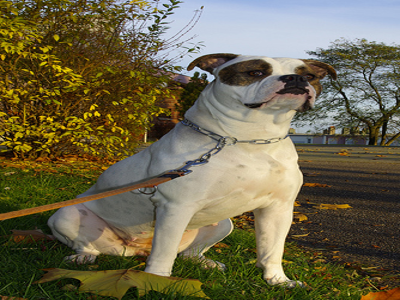

In [2]:
# ── Exercise 2: Image Classification with DINOv2 + Linear Head ──────────────

import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torchvision.datasets import OxfordIIITPet

# ── 1. Load the model with the ImageNet-1k classification head ───────────────
MODEL_ID  = "facebook/dinov2-small-imagenet1k-1-layer"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForImageClassification.from_pretrained(MODEL_ID)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on  : {device}")
print(f"Output classes   : {model.config.num_labels}")

# ── 2. Reuse an image from the already-downloaded Oxford Pet dataset ─────────
# This avoids any network request for an image URL.
# We grab a dog image (label=1) from the test split.
pet_dataset = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="binary-category",   # 0=Cat, 1=Dog
    download=False,                    # already downloaded in Exercise 1
)

# Pick a dog image (label == 1)
dog_idx = next(i for i, (_, lbl) in enumerate(pet_dataset) if lbl == 1)
image, true_label = pet_dataset[dog_idx]   # PIL Image
print(f"\nImage size : {image.size}  |  True species: {'Dog' if true_label == 1 else 'Cat'}")

# ── 3. Run inference ─────────────────────────────────────────────────────────
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits        = outputs.logits                        # (1, 1000)
probabilities = torch.softmax(logits, dim=-1)[0]      # (1000,)
top5_probs, top5_ids = torch.topk(probabilities, k=5)

# ── 4. Decode top-5 predictions ──────────────────────────────────────────────
id2label = model.config.id2label

print("\n" + "="*55)
print("       TOP-5 IMAGENET-1k PREDICTIONS")
print("="*55)
print(f"{'Rank':>4}  {'Class Name':<35}  {'Confidence':>10}")
print("-"*55)

for rank, (prob, class_id) in enumerate(zip(top5_probs, top5_ids), start=1):
    class_name = id2label[class_id.item()]
    print(f"{rank:>4}  {class_name:<35}  {prob.item():>9.2%}")

print("="*55)

top1_name = id2label[top5_ids[0].item()]
top1_conf = top5_probs[0].item()
print(f"\n✔ Predicted class : {top1_name}")
print(f"  Confidence      : {top1_conf:.2%}")

# Optional: display the image inline
display(image.resize((400, 300)))